# Task 3

Due to the simplicity of KNN for Classification, let's focus on using a Pipeline and a GridSearchCV tool, since these skills can be generalized for any model.


## The Sonar Data

### Detecting a Rock or a Mine

Sonar (sound navigation ranging) is a technique that uses sound propagation (usually underwater, as in submarine navigation) to navigate, communicate with or detect objects on or under the surface of the water, such as other vessels.



The data set contains the response metrics for 60 separate sonar frequencies sent out against a known mine field (and known rocks). These frequencies are then labeled with the known object they were beaming the sound at (either a rock or a mine).



Our main goal is to create a machine learning model capable of detecting the difference between a rock or a mine based on the response of the 60 separate sonar frequencies.


Data Source: https://archive.ics.uci.edu/ml/datasets/Connectionist+Bench+(Sonar,+Mines+vs.+Rocks)

### Complete the Tasks in bold

**TASK: Run the cells below to load the data.**

In [1]:
import numpy as np
import pandas as pd

C:\Users\Zeyad\anaconda3\lib\site-packages\pandas\core\arrays\masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [2]:
df = pd.read_csv('sonar.all-data.csv')

## Train | Test Split

Our approach here will be one of using Cross Validation on 90% of the dataset, and then judging our results on a final test set of 10% to evaluate our model.

**TASK: Split the data into features and labels, and then split into a training set and test set, with 90% for Cross-Validation training, and 10% for a final test set.**

*Note: The solution uses a random_state=42*

In [3]:
X = df.iloc[:, :-1]   # 60 feature columns
y = df.iloc[:, -1]    # label column (R or M)
print(X.shape)  # (208, 60)
print(y.shape)  # (208,)

(208, 60)
(208,)


In [4]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.1,      # 10% test
    random_state=42
)

In [5]:
print("Training set size:", X_train.shape)
print("Test set size:", X_test.shape)

Training set size: (187, 60)
Test set size: (21, 60)


**TASK: Create a Pipeline that contains both a StandardScaler and a KNN model**

In [6]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier

pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('knn', KNeighborsClassifier())
])

**TASK: Perform a grid-search with the pipeline to test various values of k and report back the best performing parameters.**

In [7]:
param_grid = {
    'knn__n_neighbors': list(range(1, 31))
}


In [8]:
from sklearn.model_selection import GridSearchCV

grid = GridSearchCV(
    pipeline,
    param_grid,
    cv=5,            # 5-fold cross validation
    scoring='accuracy'
)

In [9]:
grid.fit(X_train, y_train)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                       ('knn', KNeighborsClassifier())]),
             param_grid={'knn__n_neighbors': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11,
                                              12, 13, 14, 15, 16, 17, 18, 19,
                                              20, 21, 22, 23, 24, 25, 26, 27,
                                              28, 29, 30]},
             scoring='accuracy')

In [10]:
print("Best k:", grid.best_params_)
print("Best CV Score:", grid.best_score_)

Best k: {'knn__n_neighbors': 1}
Best CV Score: 0.8453769559032717


GridSearchCV selected k = 1 as the optimal hyperparameter, achieving a cross-validation accuracy of approximately 84.5%. While this result is consistent with typical benchmarks for the Sonar dataset, the selection of k = 1 suggests a high-variance model that may be sensitive to noise.

### Final Model Evaluation

**TASK: Using the grid classifier object from the previous step, get a final performance classification report and confusion matrix.**

In [11]:
y_pred = grid.predict(X_test)

In [12]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           M       0.92      0.92      0.92        13
           R       0.88      0.88      0.88         8

    accuracy                           0.90        21
   macro avg       0.90      0.90      0.90        21
weighted avg       0.90      0.90      0.90        21



The classifier achieved an accuracy of 90% on the test set, correctly classifying 19 out of 21 samples. Precision and recall values are balanced across both classes, indicating that the model does not exhibit a strong bias toward either rocks or mines. However, the evaluation is based on a small test set, which limits the statistical reliability of the reported performance

In [13]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[12  1]
 [ 1  7]]


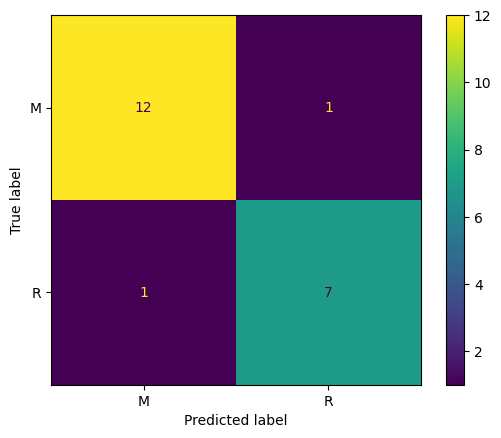

In [14]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.show()

The confusion matrix shows that the classifier correctly identified 12 out of 13 mines and 7 out of 8 rocks, resulting in only two misclassifications. The errors are evenly distributed across both classes, indicating that the model does not exhibit a strong class bias. Precision and recall are therefore balanced for both classes.